In [ ]:
from google.colab import files
import pandas as pd

print("Please upload your CSV file:")
uploaded = files.upload()

if uploaded:
  for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')

    df_uploaded = pd.read_csv(filename)
    print("File successfully loaded into a DataFrame.")
    display(df_uploaded.head())
    break
else:
  print("No file was uploaded.")

Please upload your CSV file:


Saving restaurant_consulting_dataset.csv to restaurant_consulting_dataset.csv
User uploaded file "restaurant_consulting_dataset.csv"
File successfully loaded into a DataFrame.


,date,hour,customers,avg_ticket,promo_active,weather,staff_on_shift,revenue
0,2025-01-01,11,15,22.849741,0,rainy,8,342.746112
1,2025-01-01,12,41,18.918871,0,sunny,13,775.673700
2,2025-01-01,13,42,18.901947,1,cold,13,793.881788
3,2025-01-01,14,32,28.660739,0,rainy,9,917.143664
4,2025-01-01,15,46,26.987157,1,sunny,7,1241.409232


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('restaurant_consulting_dataset.csv')


df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            1320 non-null   object 
 1   hour            1320 non-null   int64  
 2   customers       1320 non-null   int64  
 3   avg_ticket      1320 non-null   float64
 4   promo_active    1320 non-null   int64  
 5   weather         1320 non-null   object 
 6   staff_on_shift  1320 non-null   int64  
 7   revenue         1320 non-null   float64
dtypes: float64(2), int64(4), object(2)
memory usage: 82.6+ KB


# What factors most influence restaurant revenue, and how can operations be adjusted to increase it?
The objective of my analysis is to identify the key drivers of revenue for this example restaurant, and help them evaluate how their operational decisions such as optimizing staffing levels and promotional strategies impact overall performance. My goal is to determine real opportunities to improve revenue consistency, and maximize operations during both peak and non-peak periods.

## Data Overview
The dataset consists of hourly restaurant operations data, including customer counts, average ticket size, staffing levels, promotional activity, and revenue. The data spans multiple days and operating hours, allowing for analysis of both demand patterns and operational performance.

# Staffing & Revenue Stability
On busy Saturdays, particuarly within the 40-50 guest range where most of the peak activity occurs, median revenue has shown to generally increase as staffing levels rise from 8 to 11 servers.  However, this increase is not uniform across all staffing levels.

Revenue variability is lowest within the 8-10 staffing range, indicating more consistent performance at these levels.  Outside of this range, revenue outcomes become more volatile.

These findings suggest a tradeoff between maximizing revenue and maintaining operational consistency during peak demand periods.  Due to limited observations at higher customer counts(>50), conclusions for extreme high volume scenarios remain inconclusive.


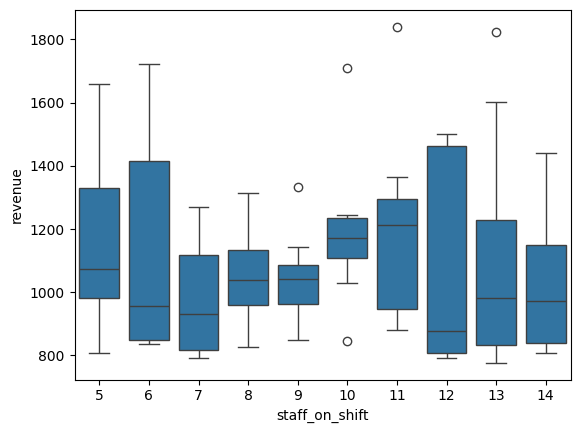

In [ ]:
sns.boxplot(data=busy_sat, x='staff_on_shift', y='revenue');

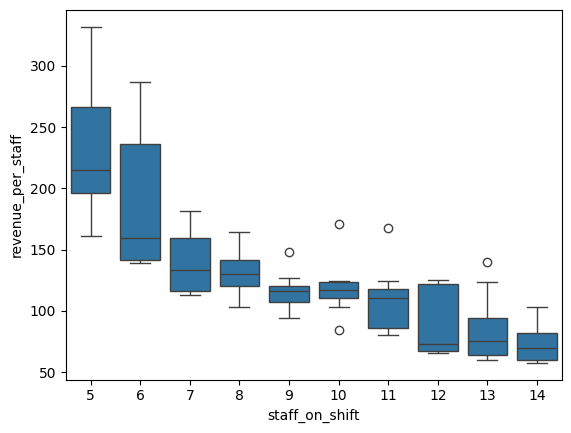

In [ ]:
sns.boxplot(data=busy_sat, x='staff_on_shift', y='revenue_per_staff');

# Revenue Drivers
Revenue is primarily driven by guest volume, with a strong and predictabile relationship observed in the 20-50 guest range, where most business occurs.  Within this range, revenue scales consistently with increases in guest count, making traffic the most reliable driver of performance.

At higher customer volumes, revenue becomes more variable with differences in performance increasingly influenced by factors other than guest count alone. While avg. ticket contributes to overall revenue, it plays a secondary role to guest volume.

This indicates that increasing customer traffic remains the most reliable lever for revenue growth, while optimizing performance at higher sales levels requires focusing on additional factors such as per person average.

<Axes: xlabel='customers', ylabel='revenue'>

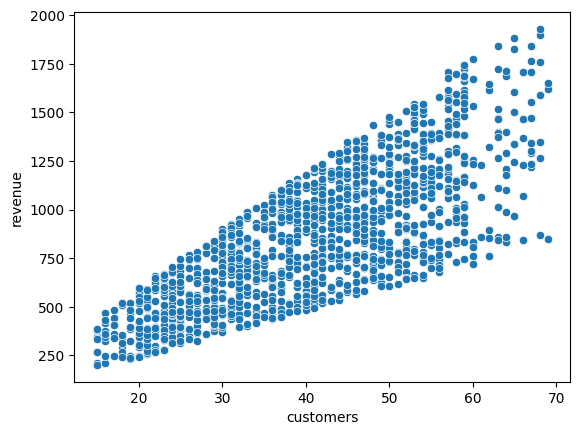

In [ ]:
sns.scatterplot(data=df, x='customers', y='revenue')

<Axes: xlabel='avg_ticket', ylabel='revenue'>

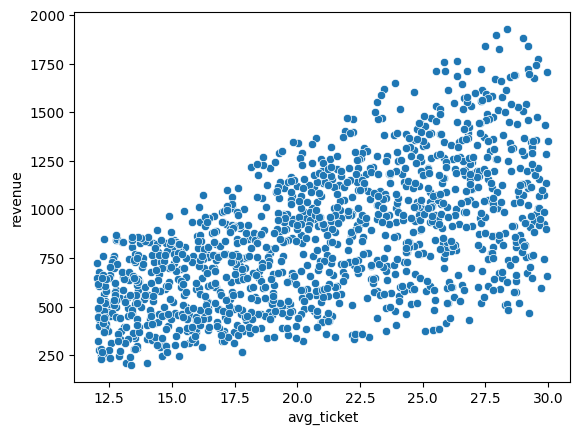

In [ ]:
sns.scatterplot(data=df, x='avg_ticket', y='revenue')

# Promotional & Revenue Tradeoffs
Promotions are associated with increased custmer volume but lower median average ticket, indicating that they primarily drive revenue through traffic rather than per person spend.

Within the 20-40 guest range, promotions contribute to higher overall revenue;however, in higher demand scenarios(40-50 guests), this effect diminishes, suggesting that promotions are less effective when demand is already strong.

Additionally, average ticket price declines during peak hours(2-9 PM), reinforcing the finding that increased traffic does not necessairly translate into higher per person average.

These findings suggest that while promotions are effective at generating demand, they may reduce overall revenue efficency without complementary strategies to increase average ticket amount.

<Axes: xlabel='promo_active', ylabel='customers'>

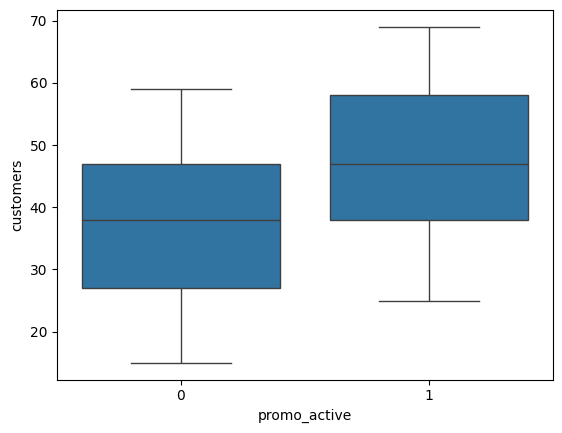

In [ ]:
sns.boxplot(data=df, x='promo_active', y='customers')

<Axes: xlabel='promo_active', ylabel='avg_ticket'>

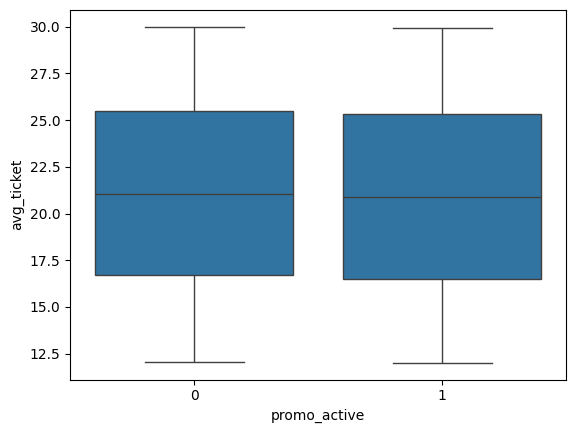

In [ ]:
sns.boxplot(data=df, x='promo_active', y='avg_ticket')

<Axes: xlabel='promo_active', ylabel='revenue'>

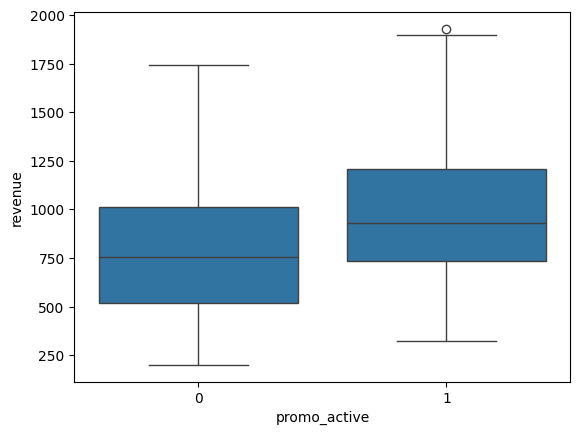

In [ ]:
sns.boxplot(data=df, x='promo_active', y='revenue')

# Final Recommendations
Based on the analysis, several operational adjustments can both improve revenue performance and consistency.

1.  **Optimize staffing within a target range:**
Maintain staffing levels within the 9-10 serverer range during high demand periods to balance revenue generation and operational stability.

2.  **Reallocate labor across demand periods:**
Shift staffing resources from lower-demand shifts to peak periods to better align labor with guest volume without increasing overall labor costs.

3. **Use promotions strategically:**
Deploy promotions during lower-demand periods, rather than during peak periods where demand is already sufficient.

4. **Increase average ticket price during peak hours:**
Implement upselling strategies, bundling, and menu optimization to capture additional revenue from existing guests, particularly during peak business hours.

5. **Focus on consistency during peak operations:**
Reduce variability in perfromance during high-demand periods by improving execution, staffing levels, and flow of service.

